In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

I0000 00:00:1779787058.549179     484 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779787058.559365     484 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779787059.478862     484 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779787062.702865     484 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
from tensorflow.keras.datasets import cifar10

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(f'Train: {x_train.shape}, {y_train.shape}')
print(f'Test: {x_test.shape}, {y_test.shape}')

Train: (50000, 32, 32, 3), (50000, 1)
Test: (10000, 32, 32, 3), (10000, 1)


In [4]:
classes = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck"
}

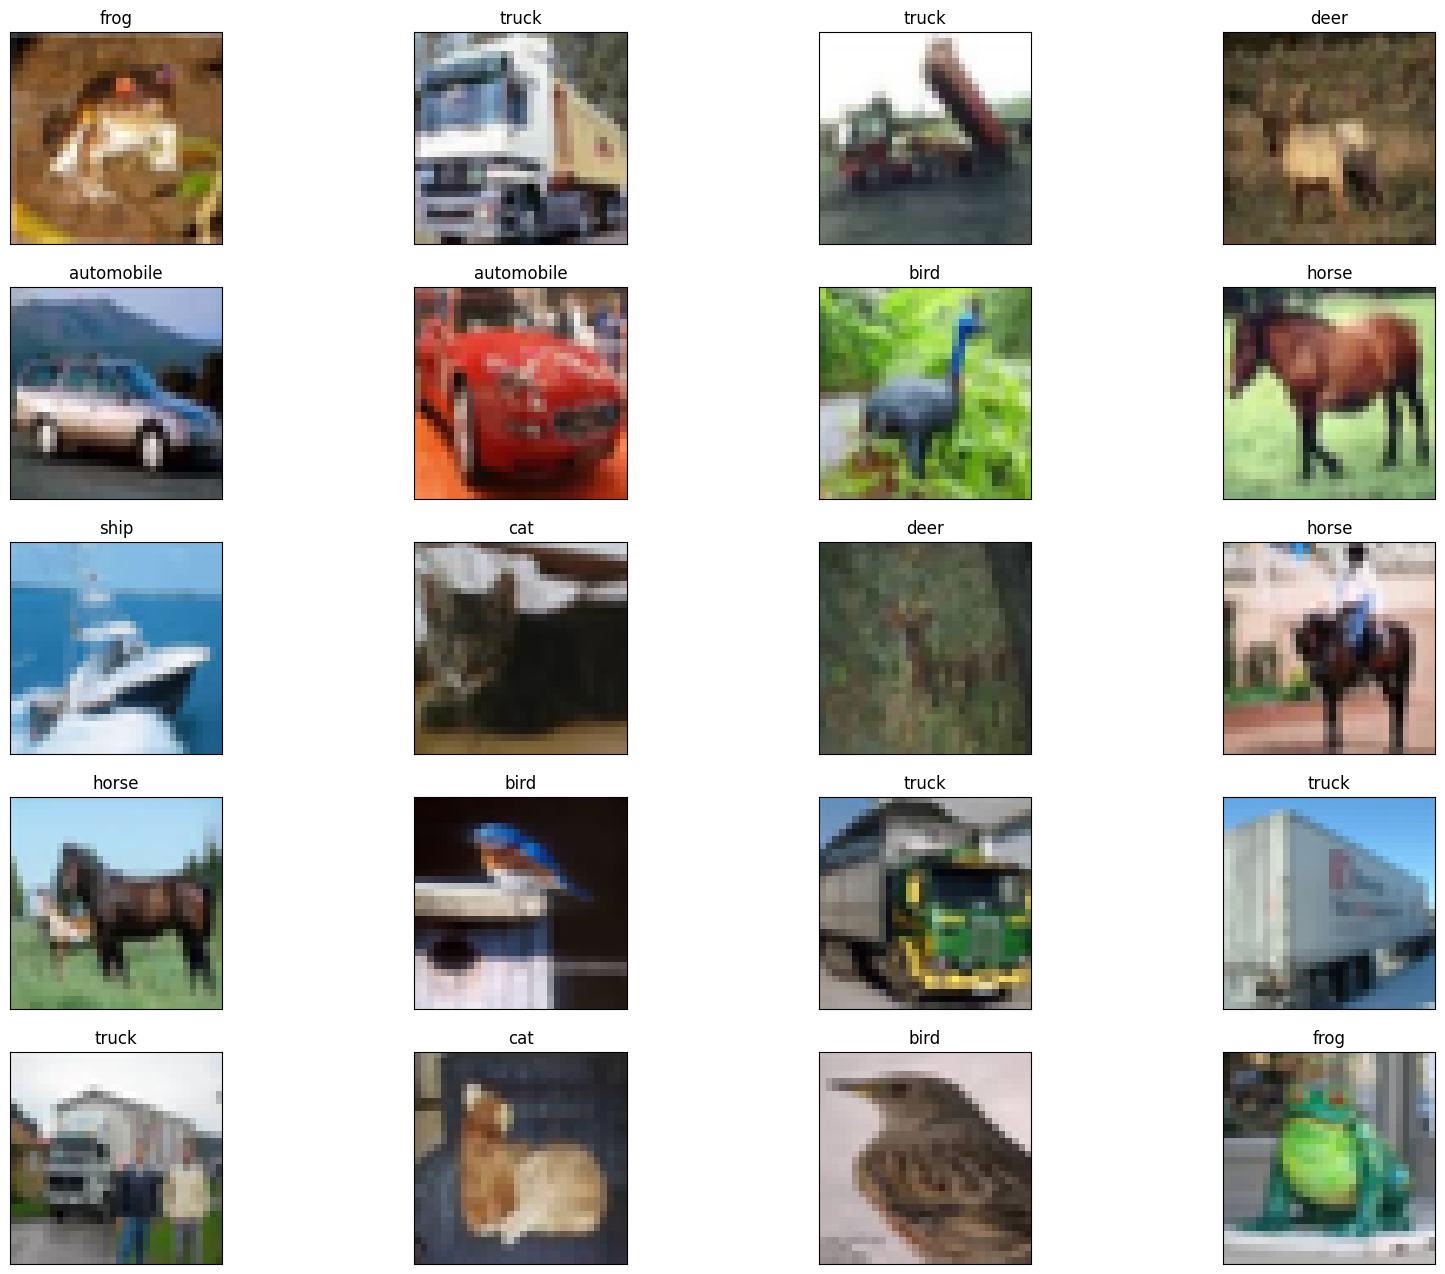

In [5]:
plt.figure(figsize = (20,16))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.imshow(x_train[i])
    plt.title(classes[y_train[i][0]])
    plt.xticks([])
    plt.yticks([])

In [6]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (32,32,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units = 128, activation = 'tanh'),
    tf.keras.layers.Dense(units = 64, activation = 'tanh'),
    tf.keras.layers.Dense(units = 32, activation = 'relu'),
    tf.keras.layers.Dense(units = 10, activation = 'softmax'),
    
])
model.summary()

E0000 00:00:1779716376.326400   17031 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,010 (1.54 MB)

 Trainable params: 404,010 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [9]:
model.compile(optimizer = tf.keras.optimizers.SGD(), metrics = ['accuracy'], loss = 'categorical_crossentropy')

In [10]:
model.fit(x_train, y_train, batch_size = 32, epochs = 50, validation_data = (x_test, y_test))

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3053 - loss: 1.9316 - val_accuracy: 0.3480 - val_loss: 1.8244
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.3822 - loss: 1.7344 - val_accuracy: 0.3843 - val_loss: 1.7167
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4100 - loss: 1.6529 - val_accuracy: 0.4261 - val_loss: 1.6248
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4298 - loss: 1.6023 - val_accuracy: 0.4360 - val_loss: 1.5761
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4436 - loss: 1.5605 - val_accuracy: 0.4274 - val_loss: 1.6100
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4593 - loss: 1.5230 - val_accuracy: 0.4230 - val_loss: 1.5939
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4677 - loss: 1.4952 - val_accuracy: 0.4581 - val_loss: 1.5196
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4766 - loss: 1.4682 - 

In [12]:
y_pr = model.predict(x_test[:20])
c = np.argmax(y_pr[:20], axis = 1)
d = np.argmax(y_test[:20], axis = 1)
print('Pred', c)
print('Real', d)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Pred [8 8 8 8 4 6 1 6 4 8 5 9 3 7 1 8 5 9 8 6]
Real [3 8 8 0 6 6 1 6 3 1 0 9 5 7 9 8 5 7 8 6]


<b>Correctly predicted 5046 of 10.000 test examples</b>

In [13]:
ds = model.predict(x_test)
ds = np.argmax(ds, axis = 1)
y_test_def = np.argmax(y_test, axis = 1)
(ds == y_test_def).sum()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


np.int64(5046)

In [14]:
wrong_pred_mask = y_test_def != ds
x_false = x_test[wrong_pred_mask]
y_false = y_test_def[wrong_pred_mask]
pred_false = ds[wrong_pred_mask]

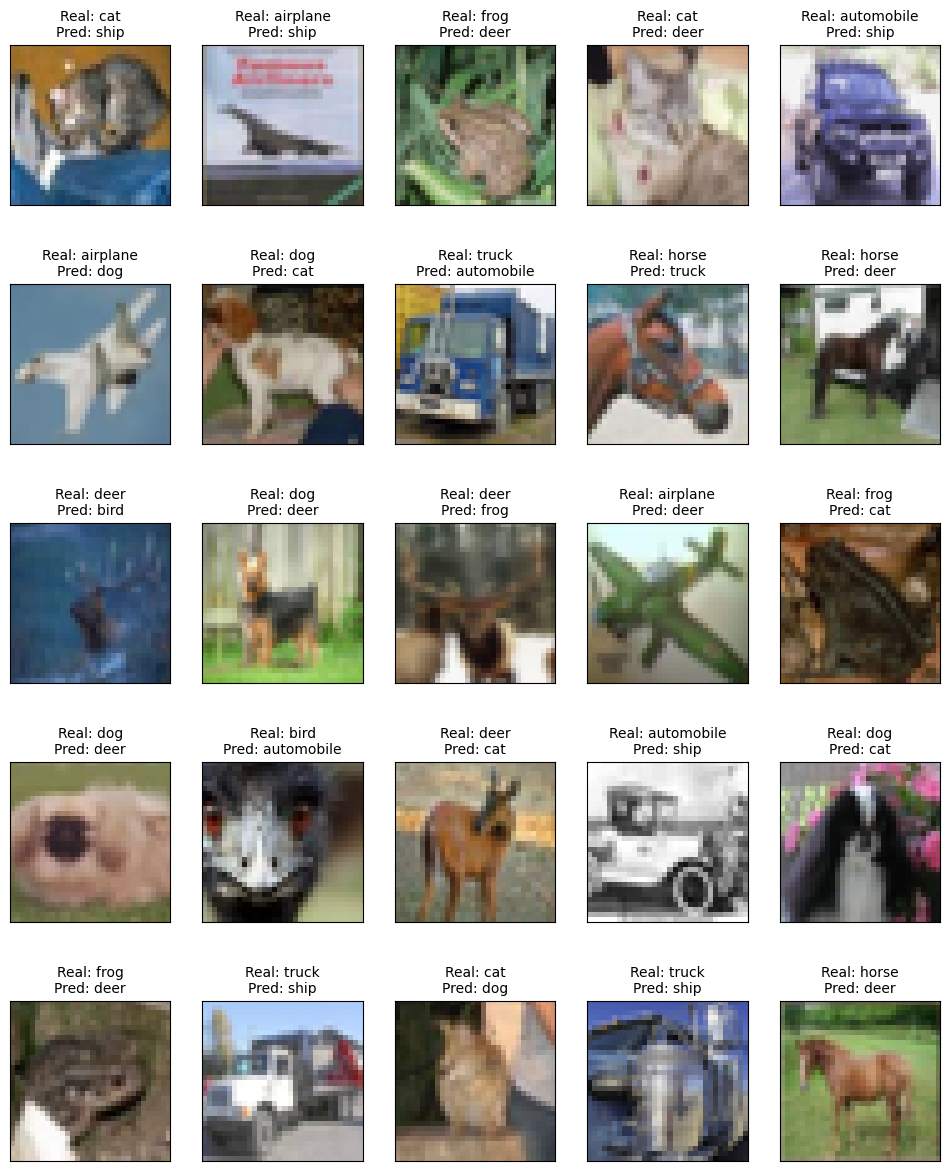

In [15]:
plt.figure(figsize = (12,15))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_false[i])
    plt.title(f'Real: {classes[y_false[i]]}\nPred: {classes[pred_false[i]]}', fontsize = 10)
    plt.xticks([])
    plt.yticks([])


In [16]:
from PIL import Image

In [70]:
def make_prediction(img_path, k = 10):
    image = Image.open(img_path)
    image = (np.array(image.resize((32,32))).astype('float32') / 255.).reshape(1,32,32,3)
    pr = model.predict(image)
    final_pred = classes[np.argmax(pr, axis = 1)[0]]
    plt.imshow(image[0])
    plt.title(f'Prediction - {final_pred}')
    plt.xticks([])
    plt.yticks([])
    print(f'First {k} probabilites')
    args = np.argsort(pr,axis=1)[0][::-1]
    prsort = np.sort(pr,axis=1)[0][::-1]
    for i in range(k):
        print(f'{classes[args[i]]}:{prsort[i]}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
First 10 probabilites
bird:0.567976713180542
deer:0.19754034280776978
frog:0.11455748230218887
cat:0.04547344520688057
airplane:0.03597487136721611
dog:0.03592262417078018
ship:0.0008955489029176533
horse:0.0007868502871133387
truck:0.0006612580036744475
automobile:0.0002108714252244681


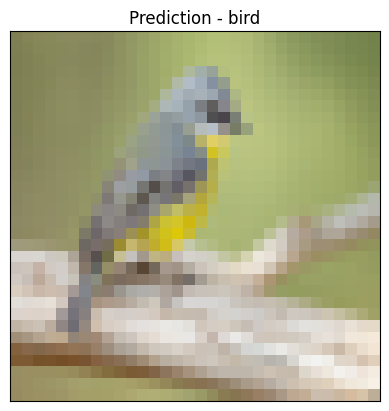

In [71]:
make_prediction("bird.jpg")

## Let's try to make predictions with regular ML algorithms

In [73]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 2.1 MB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 2.0 MB/s eta 0:00:0000:0100:04
Note: you may need to restart the kernel to use updated packages.


In [75]:
from xgboost import XGBClassifier

In [86]:
y_train_int = np.argmax(y_train, axis=1)
y_test_int  = np.argmax(y_test, axis=1)

In [87]:
xg = XGBClassifier(n_estimators = 100, max_depth = 3,  n_jobs = -1)
xg.fit(x_train.reshape(-1,32*32*3), y_train_int)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [78]:
from sklearn.metrics import accuracy_score

In [88]:
y_pr = xg.predict(x_test.reshape(-1,3072))

In [89]:
accuracy_score(y_test_int,y_pr)

0.4987

In [90]:
from sklearn.ensemble import RandomForestClassifier

In [91]:
rf = RandomForestClassifier(n_estimators = 100, max_depth = 3,  n_jobs = -1)
rf.fit(x_train.reshape(-1,32*32*3), y_train_int)
y_pr = rf.predict(x_test.reshape(-1,3072))
accuracy_score(y_test_int,y_pr)

0.2917

In [93]:
from catboost import CatBoostClassifier

In [95]:
ct = CatBoostClassifier(verbose = False)
ct.fit(x_train.reshape(-1,32*32*3), y_train_int)
y_pr = ct.predict(x_test.reshape(-1,3072))
accuracy_score(y_test_int,y_pr)

0.5673

Summary- 
FCNN's don't work well on image data, we achieved ~50% accuracy with NN, 50% with XGBoost and 29% with Random Forest. The best accuracy was reached by Catboost algorithm - 57%